The following notebook contains an alternative to Experiment 2 with log transforming the Jain index instead of standardization.

# Experiment 2

Idea: Incorporate fairness into the reward

In [1]:
import copy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    FAIRNESS_WEIGHTS_LIST,
    FIGURES_PATH,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_INITIAL_RUNS,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_TRAINING_EPISODES,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [3]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = False # demand parameters were shown in experiment 1
)

demand_model_parameters = demand_model_estimator.run_pipeline()

/Users/kisslucasara/Documents/levi-research-project/newest_codes/fair-dynamic-pricing-with-rl/src/fair_dynamic_pricing_with_rl/utils/demand_model.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q = foods_demand.groupby(by=["item_id"]).mean().reset_index()
/Users/kisslucasara/Documents/levi-research-project/newest_codes/fair-dynamic-pricing-with-rl/src/fair_dynamic_pricing_with_rl/utils/demand_model.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q_long = q.reset_index().melt(


## New environment with modified objective, including Jain's index.

In [4]:
class FMCGEnv2(FMCGEnv):
    def __init__(
        self,
        p_min: np.ndarray,
        p_max: np.ndarray,
        p_diff: np.ndarray,
        betas: list,
        noise_range: int,
        max_demand: int,
        n_snap_days: int,
        stand_params: np.ndarray=None,
        calendar_seed=None,
        T: int = 60,
        rew_weights=None,
    ):
        """Initialize FMCG Gymnasium environment.

        Args:
            p_min (np.array): minimum price vector of products (L)
            p_max (np.array): maximum price vector of products (L)
            p_diff (np.array): price step vector of products (L)
            betas (List[np.ndarray]): demand core state param. for non-SNAP and SNAP households
            noise_range (int): maximum value of noise (symmetric)
            max_demand (int): the maximum daily demand considering all L products
            n_snap_days (int): number of SNAP days in a 30-day month.
            stand_params (np.ndarray): mean and standard deviation of revenue and Jain's index (defaults to None)
            calendar_seed (int, optional): seed used for constructing SNAP calendar
            T (int, optional): length of episode (defaults to 60),
            rew_weights (np.ndarray): reward weights for profits vs. fairness tradeoff (default: 50-50%)
        """
        super().__init__(p_min, p_max,p_diff,
                         betas, noise_range, max_demand, n_snap_days, calendar_seed,
                         T)
        # reward weights default to equal weighting
        if rew_weights is None:
            self.rew_weights = np.array([0.5,0.5])
        else:
            self.rew_weights = rew_weights

        # defining new attribute
        self._stand_params = stand_params

    def _get_reward(self,
                    p: np.ndarray,
                    d: np.ndarray,
                    ):
        """ Returns reward, weighted avg. of standardized revenue and Jain's index
        Args:
            p (np.ndarray): price vector (L)
            d (np.ndarray): demand vector (L)

        Returns:
            reward (float): reward from taking action p at the given state
        """
        revenue = p @ d

        # groups are esentially the sensitive attribute mask with length t
        mask_t = np.resize(self.mask, self._t)

        jains_index, _ = compute_jains_index(action_hist=self.action_history,
                                          groups=mask_t,
                                          p_min=self.p_min,
                                          p_diff=self.p_diff)

        # fallback value for Jain's index is 1.0 (completely fair)
        # if there aren't yet enough history with both groups
        if np.isnan(jains_index):
            jains_index = 1.0

        # standardizing reward components if not initial run
        if self._stand_params is not None:
            revenue = (revenue - self._stand_params[0,0]) / self._stand_params[0,1]
            jains_index = np.log(jains_index)
            # jains_index = (jains_index - self._stand_params[1,0]) / self._stand_params[1,1]

        # weight the components of the reward
        reward = np.dot(np.array([revenue,jains_index]), self.rew_weights)
        return reward

    def _get_info(self):
        """Returns revenue"""
        # note: info returned during reset() will be 0
        if self._t > 0:
            action = self.action_history[self._t, :]
            p = self._action_to_price(action)

            revenue = p @ self._demand

            # return Jain's index for standardization
            # groups are esentially the sensitive attribute mask with length t
            mask_t = np.resize(self.mask, self._t)

            jains_index, _ = compute_jains_index(action_hist=self.action_history,
                                                groups=mask_t,
                                                p_min=self.p_min,
                                                p_diff=self.p_diff)
        else:
            revenue, jains_index = 0, 0

        return {"revenue": revenue, "jains_index": jains_index}

In [5]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv2",
    entry_point=FMCGEnv2,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [6]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  seed=None,
                  initial:bool = False):
    """ Running PPO algorithm

    Args:
        env1 (FMCGEnv2): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        seed (int): seed for reproducibility
        initial (bool): whether it is the initial run for standardization (defaults to False)

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    if initial:
        rew = np.zeros((T,K,2))
    else:
        rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=False)
            a = np.asarray(action)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            # revenue is taken to keep analysis consistent between experiments
            if not initial:
                rew[t,k] = info["revenue"]
            else:
                rew[t,k,0] = info["revenue"]
                rew[t,k,1] = info["jains_index"]
        
    return rew, action_hist, groups

## For standardization of reward components their mean and standard deviation is estimated using initial runs

In [7]:
fair_w = 0.5
env = gym.make("gymnasium_env/FMCGEnv2",
        p_min=P_MIN,
        p_max=P_MAX,
        p_diff=P_DIFF,
        betas=[params.to_numpy() for params in demand_model_parameters[3]],
        max_demand=demand_model_parameters[4],
        n_snap_days=N_SNAP_DAYS,
        calendar_seed=CALENDAR_SEED,
        T=60,
        noise_range=NOISE_RANGE,
        rew_weights=np.array([1-fair_w, fair_w])
        )

# define and warm-up algorithm
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=PPO_HYPERPARAMS["learning_rate"],
            batch_size=PPO_HYPERPARAMS["batch_size"], # default
            clip_range=PPO_HYPERPARAMS["clip_range"], # default
            seed=PPO_HYPERPARAMS["seed"],
            ent_coef=PPO_HYPERPARAMS["ent_coef"],
            )

model.learn(total_timesteps=PPO_TRAINING_EPISODES*NUM_TIMESTEPS,
            progress_bar=True)

reward_components, _, _ = running_model(env1=env,
                                        alg=model,
                                        T=NUM_TIMESTEPS,
                                        K=NUM_INITIAL_RUNS,
                                        num_products=NUM_PRODUCTS,
                                        seed=SEED_LIST[0],
                                        initial=True)

# note for the Jain's index history NA values are expected up to the time step where both groups have
# price history
standardization_params = np.array([[np.mean(reward_components[:,:,0]),np.std(reward_components[:,:,0])],
                                  [np.nanmean(reward_components[:,:,1]),np.nanstd(reward_components[:,:,1])]])

Output()

In [8]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(FAIRNESS_WEIGHTS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(FAIRNESS_WEIGHTS_LIST),5)),
                       columns=["mean_episode_revenue","jains_index","fairness_weight", "nonsnap_price", "snap_price"])

rewards_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))
action_hist_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K,NUM_PRODUCTS))
groups_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))

for idx in range(len(FAIRNESS_WEIGHTS_LIST)):
        print(f"RUN STARTED FOR FAIRNESS WEIGHT = {FAIRNESS_WEIGHTS_LIST[idx]}")
        for seed_idx in range(len(SEED_LIST)):
                print(f"RUN STARTED FOR SEED {SEED_LIST[seed_idx]}")
                # make environment with chosen revenue - fairness weights
                fair_w = FAIRNESS_WEIGHTS_LIST[idx]
                env = gym.make("gymnasium_env/FMCGEnv2",
                        p_min=P_MIN,
                        p_max=P_MAX,
                        p_diff=P_DIFF,
                        betas=[params.to_numpy() for params in demand_model_parameters[3]],
                        max_demand=demand_model_parameters[4],
                        n_snap_days=N_SNAP_DAYS,
                        stand_params=standardization_params,
                        calendar_seed=CALENDAR_SEED,
                        noise_range=NOISE_RANGE,
                        rew_weights=np.array([1-fair_w, fair_w])
                        )

                # define and warm-up algorithm
                # PPO hyperparameters from Liu et al. (2024)
                model = PPO(policy="MultiInputPolicy",
                        env=env,
                        learning_rate=PPO_HYPERPARAMS["learning_rate"],
                        batch_size=PPO_HYPERPARAMS["batch_size"], # default
                        clip_range=PPO_HYPERPARAMS["clip_range"], # default
                        seed=SEED_LIST[seed_idx],
                        ent_coef=PPO_HYPERPARAMS["ent_coef"],
                        )

                model.learn(total_timesteps=PPO_TRAINING_EPISODES*NUM_TIMESTEPS,
                        progress_bar=True)

                rewards, action_hist, groups = running_model(env1=env,
                                                        alg=model,
                                                        T=NUM_TIMESTEPS,
                                                        K=K,
                                                        num_products=NUM_PRODUCTS,
                                                        seed=SEED_LIST[seed_idx])

                rewards_over_seeds[seed_idx, ...] = rewards
                action_hist_over_seeds[seed_idx, ...] = action_hist
                groups_over_seeds[seed_idx, ...] = groups

        # save _over_seeds arrays for further analysis
        np.save(f"../output/experiment_2/rewards_over_seeds_{FAIRNESS_WEIGHTS_LIST[idx]}.npy",
                rewards_over_seeds)
        np.save(f"../output/experiment_2/action_hist_over_seeds_{FAIRNESS_WEIGHTS_LIST[idx]}.npy",
                action_hist_over_seeds)
        np.save(f"../output/experiment_2/groups_over_seeds_{FAIRNESS_WEIGHTS_LIST[idx]}.npy",
                groups_over_seeds)

        # choose based on median of last episode reward
        last_episode_rewards_over_seeds = rewards_over_seeds.sum(axis=1)[:,-1]
        median_seed_idx = argmedian(last_episode_rewards_over_seeds)

        rewards_chosen = rewards_over_seeds[median_seed_idx,...]
        action_hist_chosen = action_hist_over_seeds[median_seed_idx,...]
        groups_chosen = groups_over_seeds[median_seed_idx,...]

        episode_rewards = rewards_chosen.sum(axis=0)
        e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

        # expected mean episode rewards
        episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
        episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

        # random action probability
        episode_rewards_comparison[(idx*K):((idx+1)*K),2] = FAIRNESS_WEIGHTS_LIST[idx]

        # save main performance metrics
        results.loc[idx,"fairness_weight"] = FAIRNESS_WEIGHTS_LIST[idx]
        results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
        results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist_chosen,
                                                                        groups_chosen,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
        results.loc[idx, "nonsnap_price"] = group_values[False]
        results.loc[idx, "snap_price"] = group_values[True]

        print(f"Iteration done with mean episode revenue of {episode_rewards.mean()} and Jain's index of {results.loc[idx, "jains_index"]}.")
        print(f"Average price differences: non-SNAP: {group_values[False]} vs. SNAP: {group_values[True]}")

Output()

RUN STARTED FOR FAIRNESS WEIGHT = 0.0
RUN STARTED FOR SEED 1024


Output()

RUN STARTED FOR SEED 1224


Output()

...

Output()

RUN STARTED FOR SEED 1224


Output()

RUN STARTED FOR SEED 1424


Iteration done with mean episode revenue of 544.5465417056968 and Jain's index of 0.9999999341070713.
Average price differences: non-SNAP: 14.371353749999999 vs. SNAP: 14.363977499999999


In [ ]:
# save & print results
results.to_csv("../output/experiment_2/results.csv",
               index=False)
results

,mean_episode_revenue,jains_index,fairness_weight,nonsnap_price,snap_price
0,6810.703819,0.999769,0.000000,16.799590,16.296130
1,6852.790666,0.999704,0.111111,16.794321,16.225987
2,6829.294955,0.999743,0.222222,16.822139,16.291087
3,6751.928581,0.999969,0.333333,16.793187,16.606188
4,6749.530403,0.999971,0.444444,16.797559,16.617177
5,10077.227705,0.951206,0.555556,16.816345,10.605588
6,10428.353961,0.944632,0.666667,16.805860,10.254480
7,10282.994783,0.946622,0.777778,16.808338,10.357495
8,9969.615381,0.951385,0.888889,16.796266,10.602713
9,544.546542,1.000000,1.000000,14.371354,14.363977


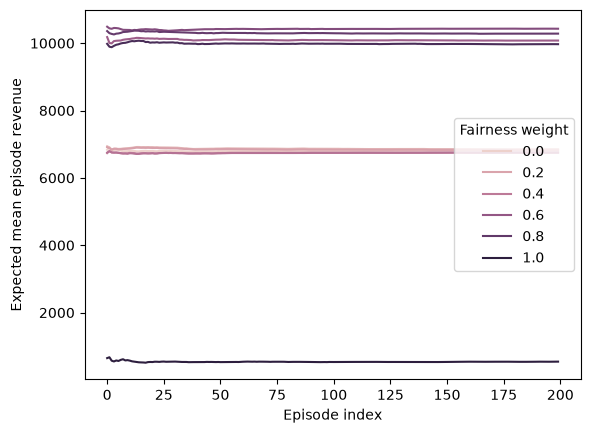

In [10]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "fairness_weight"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="fairness_weight")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Fairness weight", loc="center right")
plt.savefig(FIGURES_PATH + "experiment_2_revenue_over_time.pdf", format="pdf", bbox_inches="tight")